# Logistic Regression Model - Hyperparameter Tuning

Logistic Regression classifier for recession prediction using the selected features
on the complete (NaN-free) preprocessed dataset.

**Inputs:**
- `data/milestone_ii_preprocessed_complete.pkl` (NaN-free engineered features)
- `data/selected_features_complete.pkl` (consensus features from complete data)

**Pipeline:**
1. Data setup (identical cutoff, CV, and metrics to XGBoost)
2. StandardScaler applied per-fold (required for Logistic Regression)
3. Baseline with default hyperparameters
4. Hyperparameter tuning via Optuna (C, penalty, solver)
5. Validation-based threshold tuning (VAL_FRAC=0.2)
6. Final evaluation with per-country analysis
7. Feature coefficient analysis

**Seeds:** `random_state=42` throughout.

**Key difference from XGBoost:** Logistic Regression requires:
- No NaN values (using complete data)
- Feature scaling (StandardScaler applied per-fold to prevent leakage)
- Explicit regularization tuning (C, penalty type)

In [31]:
import pickle
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, auc,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, confusion_matrix, ConfusionMatrixDisplay
)
from model_utils import (
    compute_fold_metrics, compute_country_metrics,
    plot_roc_pr_curves, plot_confusion_matrices, plot_optuna_study,
    sweep_thresholds, plot_threshold_curves,
    build_model_comparison, export_model_config,
)

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
N_SPLITS = 5
VAL_FRAC = 0.2  # fraction of training data held out for threshold tuning

# ── Load Complete Data ────────────────────────────────────────────────────────
df = pd.read_pickle('../data/milestone_ii_preprocessed_complete.pkl')

with open('../data/selected_features_complete.pkl', 'rb') as f:
    selected_features = pickle.load(f)

df_flat = df.reset_index()
df_flat = df_flat[df_flat['date'] < '2019-01-01']

X = df_flat[selected_features].copy()
y = df_flat['pre_recession']

# Replace inf (should be none in complete data, but defensive)
X = X.replace([np.inf, -np.inf], np.nan)

print(f'Dataset shape: {df.shape}')
print(f'After pre-2019 cutoff: {len(X)} observations')
print(f'Selected features: {len(selected_features)}')
print(f'NaN count: {X.isnull().sum().sum()}')
print(f'Positive class: {y.sum()} ({y.mean():.1%})')
print(f'Date range: {df_flat["date"].min()} to {df_flat["date"].max()}')

Dataset shape: (2070, 237)
After pre-2019 cutoff: 1854 observations
Selected features: 21
NaN count: 0
Positive class: 336 (18.1%)
Date range: 2001-11-01 00:00:00 to 2018-12-01 00:00:00


## 1. Baseline Logistic Regression

Default LogisticRegression with `class_weight='balanced'` (analogous to
XGBoost's `scale_pos_weight`). StandardScaler applied per-fold to prevent
data leakage between folds.

In [32]:
tscv = TimeSeriesSplit(n_splits=N_SPLITS)
baseline_results = []
baseline_preds = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    test_countries = df_flat.iloc[test_idx]['country'].values

    # Per-fold scaling (fit on train, transform both)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = LogisticRegression(
        penalty='l2',
        C=1.0,
        solver='lbfgs',
        class_weight='balanced',
        max_iter=5000,
        random_state=RANDOM_STATE,
    )
    model.fit(X_train_scaled, y_train)

    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    y_pred = model.predict(X_test_scaled)

    roc = roc_auc_score(y_test, y_proba)
    prec_arr, rec_arr, _ = precision_recall_curve(y_test, y_proba)
    pr = auc(rec_arr, prec_arr)
    f1 = f1_score(y_test, y_pred)

    baseline_results.append({'fold': fold + 1, 'roc_auc': roc, 'pr_auc': pr, 'f1': f1})
    baseline_preds.append(pd.DataFrame({
        'country': test_countries, 'y_true': y_test.values,
        'y_pred': y_pred, 'y_proba': y_proba, 'fold': fold + 1
    }))

    train_dates = df_flat.iloc[train_idx]['date']
    test_dates = df_flat.iloc[test_idx]['date']
    print(f'Fold {fold+1}: Train to {train_dates.max().strftime("%Y-%m")}, '
          f'Test {test_dates.min().strftime("%Y-%m")}-{test_dates.max().strftime("%Y-%m")} | '
          f'ROC-AUC: {roc:.3f} | PR-AUC: {pr:.3f} | F1: {f1:.3f}')

baseline_df = pd.DataFrame(baseline_results)
baseline_pred_df = pd.concat(baseline_preds, ignore_index=True)

print(f'\nBaseline Logistic Regression (default HP, class_weight=balanced):')
print(f'  Mean ROC-AUC: {baseline_df["roc_auc"].mean():.3f} \u00b1 {baseline_df["roc_auc"].std():.3f}')
print(f'  Mean PR-AUC:  {baseline_df["pr_auc"].mean():.3f} \u00b1 {baseline_df["pr_auc"].std():.3f}')
print(f'  Mean F1:      {baseline_df["f1"].mean():.3f} \u00b1 {baseline_df["f1"].std():.3f}')

Fold 1: Train to 2004-09, Test 2004-09-2007-07 | ROC-AUC: 0.853 | PR-AUC: 0.752 | F1: 0.362
Fold 2: Train to 2007-07, Test 2007-07-2010-05 | ROC-AUC: 0.852 | PR-AUC: 0.650 | F1: 0.661
Fold 3: Train to 2010-05, Test 2010-06-2013-04 | ROC-AUC: 0.749 | PR-AUC: 0.496 | F1: 0.507
Fold 4: Train to 2013-04, Test 2013-04-2016-02 | ROC-AUC: 0.767 | PR-AUC: 0.383 | F1: 0.295
Fold 5: Train to 2016-02, Test 2016-02-2018-12 | ROC-AUC: 0.390 | PR-AUC: 0.150 | F1: 0.120

Baseline Logistic Regression (default HP, class_weight=balanced):
  Mean ROC-AUC: 0.722 ± 0.192
  Mean PR-AUC:  0.486 ± 0.235
  Mean F1:      0.389 ± 0.206


## 2. Hyperparameter Tuning with Optuna

Bayesian optimization of Logistic Regression hyperparameters:
- **C**: Inverse regularization strength \[1e-4, 100\] (log scale)
- **penalty**: l1, l2, or elasticnet
- **solver**: Matched to penalty (saga for l1/elasticnet, lbfgs or saga for l2)
- **l1_ratio**: Only for elasticnet penalty

Scoring: ROC-AUC (prevents degenerate constant-prediction solutions that can
inflate PR-AUC without actually learning to rank).

`class_weight='balanced'` is always used (Logistic Regression equivalent of
XGBoost's per-fold `scale_pos_weight`).

In [33]:
N_OPTUNA_TRIALS = 200

tscv = TimeSeriesSplit(n_splits=N_SPLITS)
folds = list(tscv.split(X))


def optuna_objective(trial):
    """Optuna objective: maximize mean ROC-AUC across CV folds."""
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2', 'elasticnet'])
    C = trial.suggest_float('C', 1e-4, 100.0, log=True)

    # Solver must match penalty type
    if penalty == 'l2':
        solver = trial.suggest_categorical('solver_l2', ['lbfgs', 'saga'])
    else:
        solver = 'saga'  # saga required for l1 and elasticnet

    params = {
        'penalty': penalty,
        'C': C,
        'solver': solver,
        'class_weight': 'balanced',
        'max_iter': 5000,
        'random_state': RANDOM_STATE,
    }

    if penalty == 'elasticnet':
        params['l1_ratio'] = trial.suggest_float('l1_ratio', 0.0, 1.0)

    fold_roc = []
    for train_idx, test_idx in folds:
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s = scaler.transform(X_test)

        try:
            model = LogisticRegression(**params)
            model.fit(X_train_s, y_train)
            y_proba = model.predict_proba(X_test_s)[:, 1]
            fold_roc.append(roc_auc_score(y_test, y_proba))
        except Exception:
            return 0.0  # Invalid config

    return float(np.mean(fold_roc))


print(f'Optuna: Running {N_OPTUNA_TRIALS} trials with TPE sampler...')

study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=RANDOM_STATE),
    study_name='logistic_regression_recession',
)
study.optimize(optuna_objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=True)

# Extract best params, cleaning up conditional solver parameter
best_params = study.best_params.copy()
if 'solver_l2' in best_params:
    if best_params.get('penalty') == 'l2':
        best_params['solver'] = best_params.pop('solver_l2')
    else:
        best_params.pop('solver_l2')
        best_params['solver'] = 'saga'
elif 'solver' not in best_params:
    best_params['solver'] = 'saga'

print(f'\nOptuna search complete ({len(study.trials)} trials)')
print(f'Best ROC-AUC: {study.best_value:.4f}')
print(f'\nBest hyperparameters:')
for param, val in sorted(best_params.items()):
    print(f'  {param}: {val:.4f}' if isinstance(val, float) else f'  {param}: {val}')

Optuna: Running 200 trials with TPE sampler...


  0%|          | 0/200 [00:00<?, ?it/s]


Optuna search complete (200 trials)
Best ROC-AUC: 0.7469

Best hyperparameters:
  C: 0.0104
  penalty: l2
  solver: saga


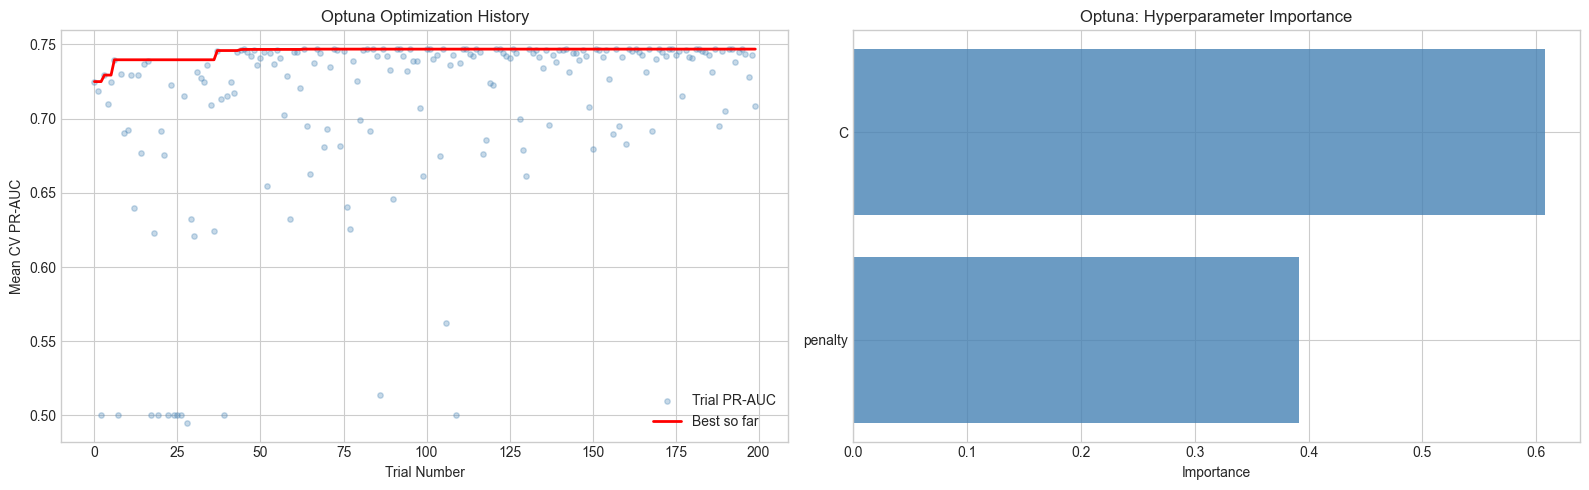

In [34]:
plot_optuna_study(study)

## 3. Evaluate Tuned Hyperparameters

In [35]:
# ── Evaluate Tuned HP ─────────────────────────────────────────────────────────
tscv = TimeSeriesSplit(n_splits=N_SPLITS)
tuned_results = []
tuned_preds = []
val_preds = []

lr_params = {
    'penalty': best_params['penalty'],
    'C': best_params['C'],
    'solver': best_params['solver'],
    'class_weight': 'balanced',
    'max_iter': 5000,
    'random_state': RANDOM_STATE,
}
if best_params['penalty'] == 'elasticnet':
    lr_params['l1_ratio'] = best_params['l1_ratio']

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train_full, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train_full, y_test = y.iloc[train_idx], y.iloc[test_idx]
    test_countries = df_flat.iloc[test_idx]['country'].values

    # Split training data into train/val for threshold tuning
    val_size = int(len(X_train_full) * VAL_FRAC)
    X_train = X_train_full.iloc[:-val_size]
    y_train = y_train_full.iloc[:-val_size]
    X_val = X_train_full.iloc[-val_size:]
    y_val = y_train_full.iloc[-val_size:]

    # Per-fold scaling (fit on train, transform val and test)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    model = LogisticRegression(**lr_params)
    model.fit(X_train_scaled, y_train)

    # Validation predictions for threshold tuning
    val_proba = model.predict_proba(X_val_scaled)[:, 1]
    val_preds.append(pd.DataFrame({
        'y_true': y_val.values, 'y_proba': val_proba, 'fold': fold + 1
    }))

    # Test predictions for final evaluation
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    y_pred = model.predict(X_test_scaled)

    roc = roc_auc_score(y_test, y_proba)
    prec_arr, rec_arr, _ = precision_recall_curve(y_test, y_proba)
    pr = auc(rec_arr, prec_arr)
    f1 = f1_score(y_test, y_pred)

    tuned_results.append({'fold': fold + 1, 'roc_auc': roc, 'pr_auc': pr, 'f1': f1})
    tuned_preds.append(pd.DataFrame({
        'country': test_countries, 'y_true': y_test.values,
        'y_pred': y_pred, 'y_proba': y_proba, 'fold': fold + 1
    }))

    train_dates = df_flat.iloc[train_idx]['date']
    test_dates = df_flat.iloc[test_idx]['date']
    print(f'Fold {fold+1}: Train to {train_dates.max().strftime("%Y-%m")}, '
          f'Test {test_dates.min().strftime("%Y-%m")}-{test_dates.max().strftime("%Y-%m")} | '
          f'ROC-AUC: {roc:.3f} | PR-AUC: {pr:.3f} | F1: {f1:.3f}')

tuned_df = pd.DataFrame(tuned_results)
tuned_pred_df = pd.concat(tuned_preds, ignore_index=True)
val_pred_df = pd.concat(val_preds, ignore_index=True)

print(f'\nTuned hyperparameters (default threshold=0.5):')
print(f'  Mean ROC-AUC: {tuned_df["roc_auc"].mean():.3f} \u00b1 {tuned_df["roc_auc"].std():.3f}')
print(f'  Mean PR-AUC:  {tuned_df["pr_auc"].mean():.3f} \u00b1 {tuned_df["pr_auc"].std():.3f}')
print(f'  Mean F1:      {tuned_df["f1"].mean():.3f} \u00b1 {tuned_df["f1"].std():.3f}')

Fold 1: Train to 2004-09, Test 2004-09-2007-07 | ROC-AUC: 0.334 | PR-AUC: 0.186 | F1: 0.000
Fold 2: Train to 2007-07, Test 2007-07-2010-05 | ROC-AUC: 0.812 | PR-AUC: 0.576 | F1: 0.167
Fold 3: Train to 2010-05, Test 2010-06-2013-04 | ROC-AUC: 0.750 | PR-AUC: 0.496 | F1: 0.135
Fold 4: Train to 2013-04, Test 2013-04-2016-02 | ROC-AUC: 0.726 | PR-AUC: 0.275 | F1: 0.226
Fold 5: Train to 2016-02, Test 2016-02-2018-12 | ROC-AUC: 0.395 | PR-AUC: 0.148 | F1: 0.113

Tuned hyperparameters (default threshold=0.5):
  Mean ROC-AUC: 0.603 ± 0.221
  Mean PR-AUC:  0.336 ± 0.190
  Mean F1:      0.128 ± 0.083


## 4. Threshold Tuning (Validation-Based)

Sweep thresholds on **validation** predictions (20% held-out tail of each
training fold) and select the threshold that maximizes F1. Test-fold metrics
at that threshold are reported for unbiased evaluation.

**Naive baselines we must beat** (to demonstrate the model has learned something useful):
- **Predict-all-positive**: Precision = prevalence, Recall = 1.0, F1 = 2 * prevalence / (1 + prevalence)
- **Predict-all-negative**: F1 = 0 (no true positives)
- **Random classifier**: ROC-AUC = 0.5, PR-AUC ≈ prevalence

Optimal threshold (from validation data): 0.17
  Mean validation F1 at optimal threshold: 0.339

  Test F1 at optimal threshold:        0.302
  Test Precision at optimal threshold:  0.273
  Test Recall at optimal threshold:     0.454
  Test F1 at default threshold (0.50):  0.128

Naive baselines (must beat these):
  Predict-all-positive F1: 0.329
  Predict-all-negative F1: 0.000
  Random classifier ROC-AUC: 0.500
  Random classifier PR-AUC:  0.199 (= class prevalence)


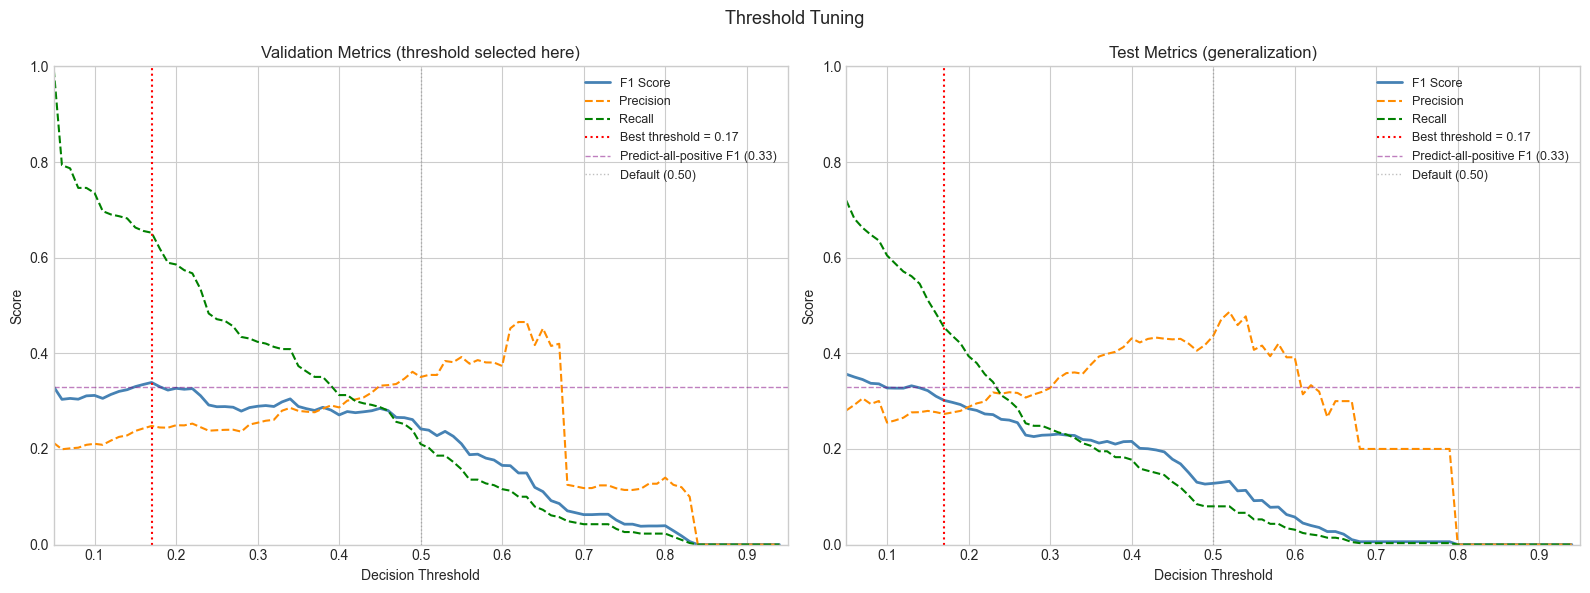

In [36]:
# ── Validation-Based Threshold Tuning ─────────────────────────────────────────
# Sweep validation metrics — threshold is selected here
(thresholds, mean_val_f1, mean_val_prec, mean_val_rec,
 _, _) = sweep_thresholds(val_pred_df, N_SPLITS)
best_threshold_idx = np.argmax(mean_val_f1)
best_threshold = thresholds[best_threshold_idx]

print(f'Optimal threshold (from validation data): {best_threshold:.2f}')
print(f'  Mean validation F1 at optimal threshold: {mean_val_f1[best_threshold_idx]:.3f}')

# Sweep test metrics — for visualization / reporting only
(_, mean_test_f1, mean_test_prec, mean_test_rec,
 naive_f1, mean_prevalence) = sweep_thresholds(tuned_pred_df, N_SPLITS)

# Apply optimal threshold to test predictions
tuned_pred_df['y_pred_opt'] = (tuned_pred_df['y_proba'] >= best_threshold).astype(int)

print(f'\n  Test F1 at optimal threshold:        {mean_test_f1[best_threshold_idx]:.3f}')
print(f'  Test Precision at optimal threshold:  {mean_test_prec[best_threshold_idx]:.3f}')
print(f'  Test Recall at optimal threshold:     {mean_test_rec[best_threshold_idx]:.3f}')
print(f'  Test F1 at default threshold (0.50):  {mean_test_f1[np.argmin(np.abs(thresholds - 0.5))]:.3f}')
print(f'\nNaive baselines (must beat these):')
print(f'  Predict-all-positive F1: {naive_f1:.3f}')
print(f'  Predict-all-negative F1: 0.000')
print(f'  Random classifier ROC-AUC: 0.500')
print(f'  Random classifier PR-AUC:  {mean_prevalence:.3f} (= class prevalence)')

fig, (ax_val, ax_test) = plt.subplots(1, 2, figsize=(16, 6))

# Left: Validation metrics (threshold selected here)
plot_threshold_curves(thresholds, mean_val_f1, mean_val_prec, mean_val_rec,
                      best_threshold, naive_f1,
                      ax=ax_val, title='Validation Metrics (threshold selected here)')

# Right: Test metrics (generalization)
plot_threshold_curves(thresholds, mean_test_f1, mean_test_prec, mean_test_rec,
                      best_threshold, naive_f1,
                      ax=ax_test, title='Test Metrics (generalization)')

plt.suptitle('Threshold Tuning', fontsize=13)
plt.tight_layout()
plt.show()

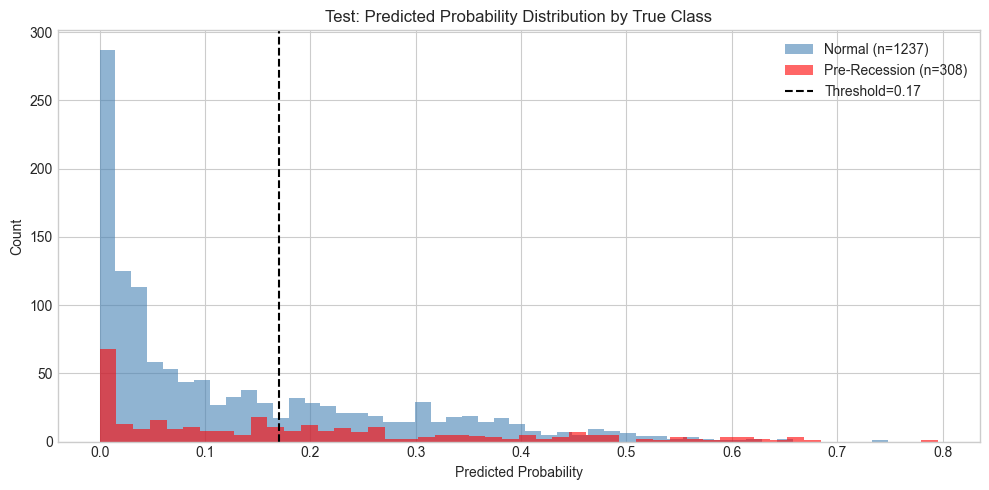

Test: Normal mean proba = 0.130, Pre-Recession mean proba = 0.187
Class separation (difference in means): 0.057


In [37]:
# ── Predicted Probability Distribution ────────────────────────────────────────
# Diagnostic: shows whether the model separates classes in probability space.

fig, ax = plt.subplots(figsize=(10, 5))

pos_test = tuned_pred_df[tuned_pred_df['y_true'] == 1]['y_proba']
neg_test = tuned_pred_df[tuned_pred_df['y_true'] == 0]['y_proba']

ax.hist(neg_test, bins=50, alpha=0.6, label=f'Normal (n={len(neg_test)})', color='steelblue')
ax.hist(pos_test, bins=50, alpha=0.6, label=f'Pre-Recession (n={len(pos_test)})', color='red')
ax.axvline(best_threshold, color='black', linestyle='--', linewidth=1.5,
           label=f'Threshold={best_threshold:.2f}')
ax.set_title('Test: Predicted Probability Distribution by True Class')
ax.set_xlabel('Predicted Probability')
ax.set_ylabel('Count')
ax.legend()

plt.tight_layout()
plt.show()

print(f'Test: Normal mean proba = {neg_test.mean():.3f}, Pre-Recession mean proba = {pos_test.mean():.3f}')
print(f'Class separation (difference in means): {pos_test.mean() - neg_test.mean():.3f}')

## 5. Final Model Evaluation

In [38]:
final_df = compute_fold_metrics(tuned_pred_df, N_SPLITS, best_threshold)

Per-Fold Metrics (tuned HP + optimal threshold)
 fold  accuracy  precision  recall    f1  roc_auc  pr_auc
    1     0.786      0.000   0.000 0.000    0.334   0.186
    2     0.806      0.562   0.409 0.474    0.812   0.576
    3     0.709      0.490   0.580 0.531    0.750   0.496
    4     0.537      0.209   0.837 0.335    0.726   0.275
    5     0.359      0.104   0.444 0.168    0.395   0.148

Mean ± Std:
  accuracy    : 0.639 ± 0.189
  precision   : 0.273 ± 0.244
  recall      : 0.454 ± 0.304
  f1          : 0.302 ± 0.219
  roc_auc     : 0.603 ± 0.221
  pr_auc      : 0.336 ± 0.190


In [39]:
country_df = compute_country_metrics(tuned_pred_df)

Per-Country Classification Metrics (Tuned Model, Aggregated Across All CV Folds)
             Accuracy  Precision  Recall    F1  ROC-AUC  PR-AUC  Support (pos)  Total
Country                                                                              
Australia       0.351      0.156   0.472 0.234    0.444   0.301             36    171
Canada          0.684      0.281   0.225 0.250    0.541   0.294             40    171
France          0.871      0.800   0.387 0.522    0.654   0.557             31    171
Germany         0.738      0.378   0.389 0.384    0.713   0.490             36    172
Italy           0.523      0.220   0.645 0.328    0.648   0.357             31    172
Japan           0.634      0.308   0.372 0.337    0.562   0.354             43    172
South Korea     0.552      0.293   0.692 0.412    0.605   0.391             39    172
UK              0.878      0.333   0.312 0.323    0.569   0.247             16    172
USA             0.523      0.189   0.389 0.255    0.449   0

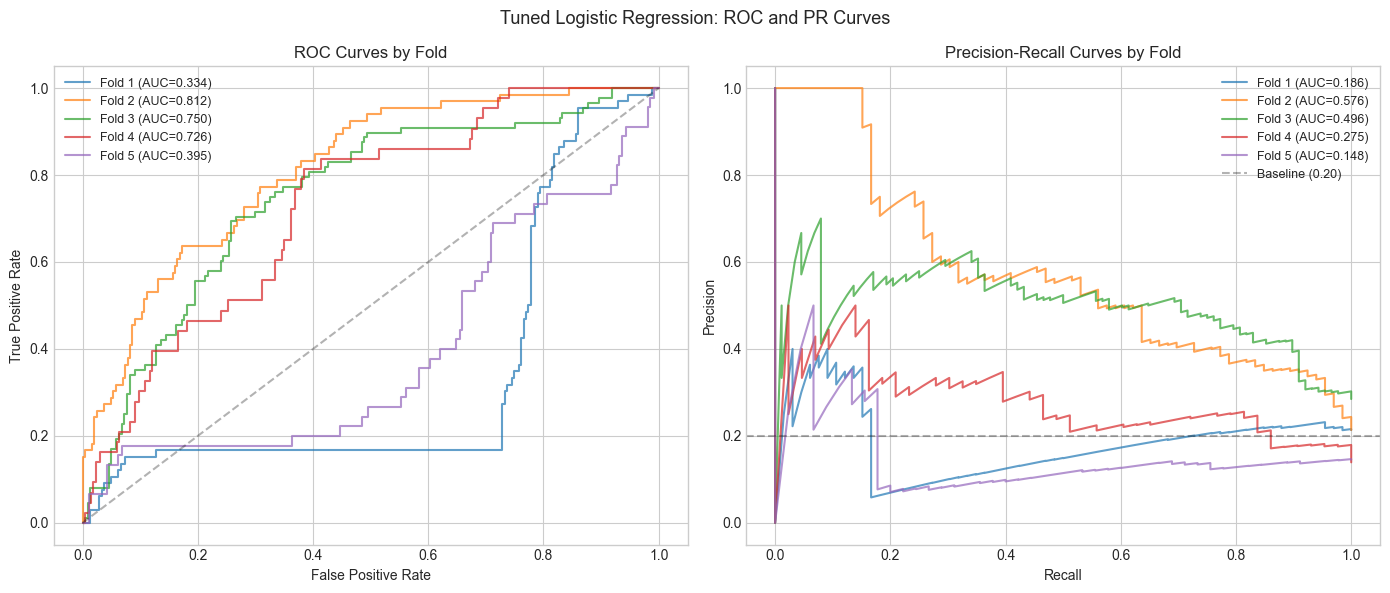

In [40]:
plot_roc_pr_curves(tuned_pred_df, N_SPLITS, 'Logistic Regression')

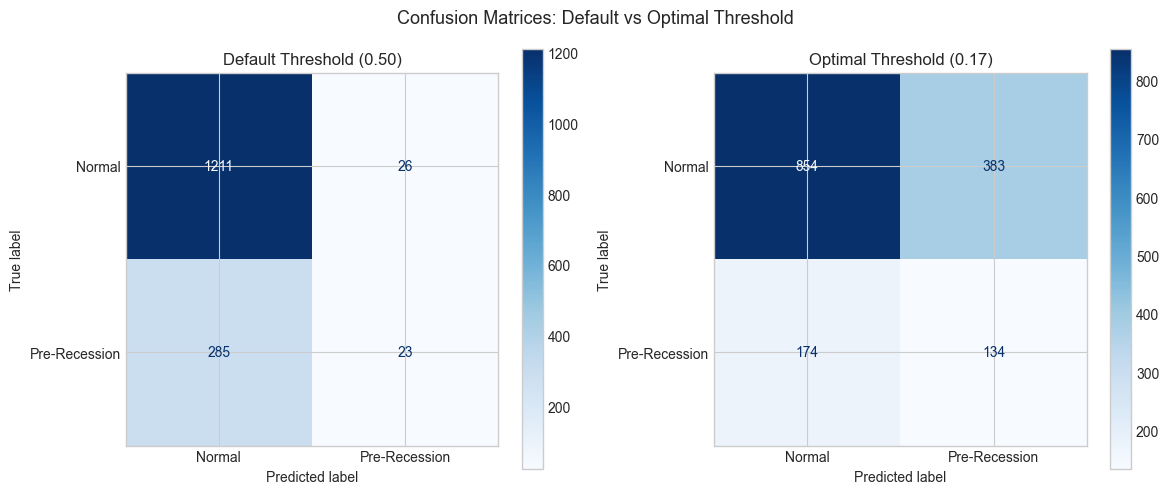

In [41]:
plot_confusion_matrices(tuned_pred_df, best_threshold)

## 6. Feature Coefficient Analysis

Logistic Regression coefficients are directly interpretable: positive coefficients
increase the log-odds of pre-recession, negative coefficients decrease it.
Coefficients are on the standardized scale (after StandardScaler) and averaged
across CV folds for stability.

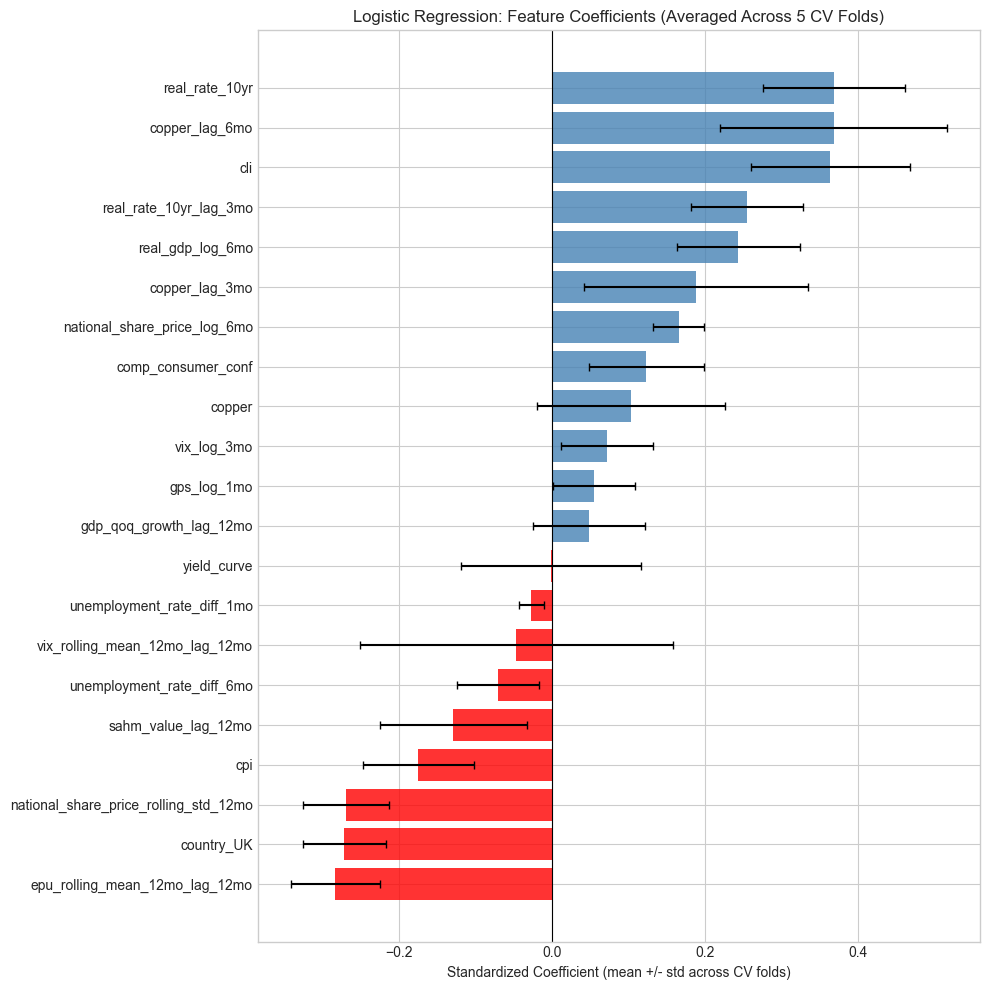

Feature Coefficient Ranking (by absolute value, mean +/- std across folds):
   1. real_rate_10yr                                      +0.3691 +/- 0.0927
   2. copper_lag_6mo                                      +0.3680 +/- 0.1486
   3. cli                                                 +0.3639 +/- 0.1041
   4. epu_rolling_mean_12mo_lag_12mo                      -0.2837 +/- 0.0583
   5. country_UK                                          -0.2715 +/- 0.0548
   6. national_share_price_rolling_std_12mo               -0.2697 +/- 0.0561
   7. real_rate_10yr_lag_3mo                              +0.2547 +/- 0.0737
   8. real_gdp_log_6mo                                    +0.2432 +/- 0.0803
   9. copper_lag_3mo                                      +0.1883 +/- 0.1466
  10. cpi                                                 -0.1748 +/- 0.0721
  11. national_share_price_log_6mo                        +0.1653 +/- 0.0333
  12. sahm_value_lag_12mo                                 -0.1289 +/- 0.0964


In [42]:
# Average coefficients across CV folds for reliable estimates
tscv = TimeSeriesSplit(n_splits=N_SPLITS)
fold_coefficients = np.zeros((N_SPLITS, len(selected_features)))

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    model = LogisticRegression(**lr_params)
    model.fit(X_train_scaled, y_train)
    fold_coefficients[fold] = model.coef_[0]

mean_coefficients = fold_coefficients.mean(axis=0)
std_coefficients = fold_coefficients.std(axis=0)

coef_df = pd.DataFrame({
    'feature': selected_features,
    'coefficient': mean_coefficients,
    'std': std_coefficients
}).sort_values('coefficient', key=abs, ascending=False)

# Horizontal bar plot with error bars and positive (blue) / negative (red) coloring
fig, ax = plt.subplots(figsize=(10, 10))
plot_data = coef_df.sort_values('coefficient', ascending=True)
colors = ['red' if v < 0 else 'steelblue' for v in plot_data['coefficient']]
ax.barh(plot_data['feature'], plot_data['coefficient'], xerr=plot_data['std'],
        color=colors, alpha=0.8, capsize=3)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Standardized Coefficient (mean +/- std across CV folds)')
ax.set_title(f'Logistic Regression: Feature Coefficients (Averaged Across {N_SPLITS} CV Folds)')
plt.tight_layout()
plt.show()

print('Feature Coefficient Ranking (by absolute value, mean +/- std across folds):')
for i, (_, row) in enumerate(coef_df.iterrows(), 1):
    sign = '+' if row['coefficient'] > 0 else '-'
    print(f'  {i:2d}. {row["feature"]:50s}  {sign}{abs(row["coefficient"]):.4f} +/- {row["std"]:.4f}')

## 7. Baseline vs Tuned Comparison

In [43]:
comparison = build_model_comparison(
    baseline_df, baseline_pred_df,
    tuned_df, tuned_pred_df,
    final_df, best_threshold,
    naive_f1, mean_prevalence,
    model_name='Logistic Regression',
)

Logistic Regression Model Comparison
                               ROC-AUC  PR-AUC    F1  Accuracy  Precision  Recall
Model                                                                            
Naive: Predict All Negative      0.500   0.199 0.000     0.801      0.000   0.000
Naive: Predict All Positive      0.500   0.199 0.329     0.199      0.199   1.000
Baseline (default HP, t=0.50)    0.722   0.486 0.389     0.719      0.356   0.503
Tuned HP (t=0.50)                0.603   0.336 0.128     0.799      0.469   0.075
Tuned HP + Threshold (t=0.17)    0.603   0.336 0.302     0.639      0.259   0.435

Improvement (Tuned HP + Threshold vs Baseline):
  ROC-AUC     : -0.119
  PR-AUC      : -0.150
  F1          : -0.087
  Precision   : -0.096
  Recall      : -0.068

Beats naive baselines?
  F1 (0.302) > predict-all-positive (0.329): False
  ROC-AUC (0.603) > random (0.500): True
  PR-AUC (0.336) > prevalence (0.199): True


## 8. Export Model Configuration

In [44]:
export_model_config(best_params, best_threshold, selected_features, final_df,
                    '../data/logistic_regression_model_config.pkl', dataset='complete')

Exported to: data/logistic_regression_model_config.pkl

Model Configuration:
  Features:    21
  Threshold:   0.17
  Random state: 42

  Hyperparameters:
    C: 0.0104
    penalty: l2
    solver: saga

  CV Performance:
    ROC-AUC: 0.603 ± 0.221
    PR-AUC:  0.336 ± 0.190
    F1:      0.302 ± 0.219


## Summary

| Stage | Description |
|-------|-------------|
| Baseline | LogisticRegression with default HP (l2, C=1.0), class_weight='balanced' |
| HP tuning (Optuna) | 200 trials with TPE; search over C, penalty, solver, l1_ratio |
| Threshold | Validation-based: maximize F1 on 20% held-out tail of each training fold |
| Final evaluation | Best HP + optimal threshold, per-fold and per-country metrics |

**Key design choices:**
- Per-fold StandardScaler (fit on train, transform val and test) to prevent data leakage
- `class_weight='balanced'` for all models (LR equivalent of XGBoost's `scale_pos_weight`)
- Threshold selected on validation data, metrics reported on test folds (unbiased)

**Consistency with XGBoost:**
- `random_state=42` for all models
- `TimeSeriesSplit(n_splits=5)` for all cross-validation
- `VAL_FRAC=0.2` validation split for threshold tuning
- Data cutoff at 2019-01-01 (pre-COVID contamination excluded)
- Same selected features from consensus feature selection (complete data)
- Same evaluation metrics (ROC-AUC, PR-AUC, F1, Accuracy, Precision, Recall)

**Exported:** `data/logistic_regression_model_config.pkl`